In [2]:
import sys
sys.path.append('../../../../src')
import pickle
from energiapy.plot import plot_results, plot_scenario, plot_location
from matplotlib import pyplot as plt
from matplotlib import rc
import numpy as np

In [3]:
dark_colors = [
    "black",
    "dimgray",
    "gray",
    "dimgrey",
    "slategrey",
    "darkslategray",
    "darkslategrey",
    "darkgray",
    "darkblue",
    "midnightblue",
    "navy",
    "darkgreen",
    "forestgreen",
    "darkolivegreen",
    "darkred",
    "firebrick",
    "maroon",
    "darkmagenta",
    "indigo",
    "darkviolet",
    "purple",
    "darkorange",
    "saddlebrown",
    "chocolate",
    "darkgoldenrod"
]

In [4]:
with open(f'control/ncl_ControlResults_Backlog.pkl', 'rb') as file:
    ncl_load_results = pickle.load(file)

In [5]:
with open(f'control/cl_ControlResults_Backlog.pkl', 'rb') as file:
    cl_load_results = pickle.load(file)

In [6]:
with open(f'control/cl_step2_ControlResults_Backlog.pkl', 'rb') as file:
    cl_step2_load_results = pickle.load(file)

In [7]:
with open(f'control/cl_step2_ControlResults_Backlog_ncl_des.pkl', 'rb') as file:
    cl_step2_ncl_des_load_results = pickle.load(file)

In [8]:
# with open(f'control/ncl_ControlResults_Backlog_ph30.pkl', 'rb') as file:
#     ph30_ncl_load_results = pickle.load(file)

In [9]:
# with open(f'control/cl_ControlResults_Backlog_ph30.pkl', 'rb') as file:
#     ph30_cl_load_results = pickle.load(file)

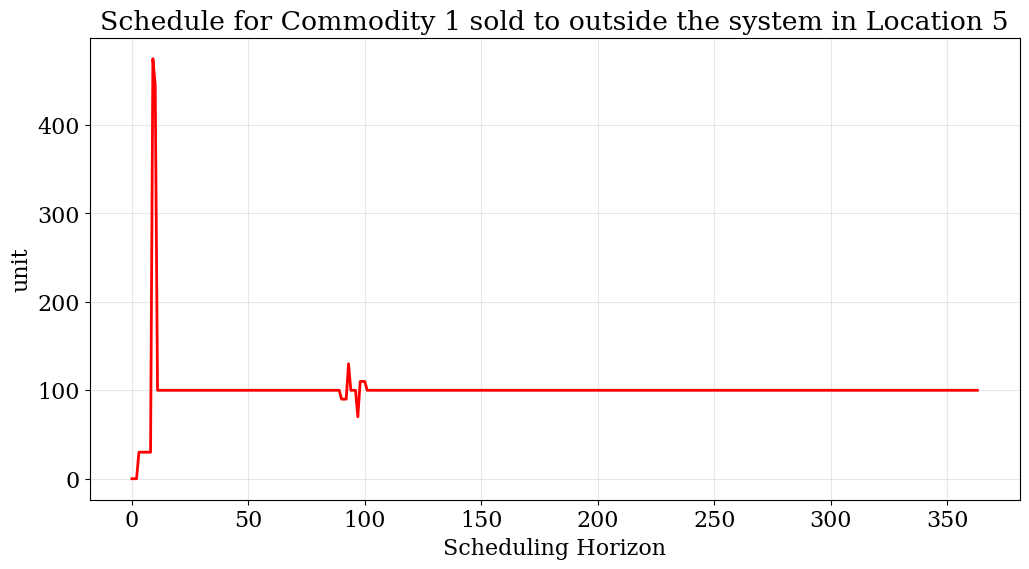

In [10]:
plot_results.schedule(results=ncl_load_results, y_axis='S', component='com1_sold', location='loc5', color='red')

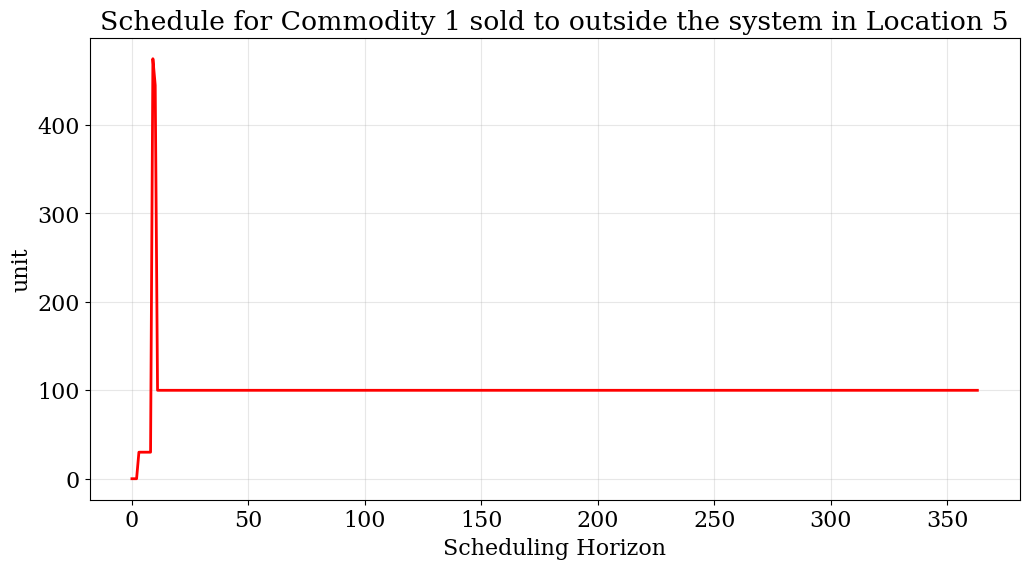

In [11]:
plot_results.schedule(results=cl_load_results, y_axis='S', component='com1_sold', location='loc5', color='red')

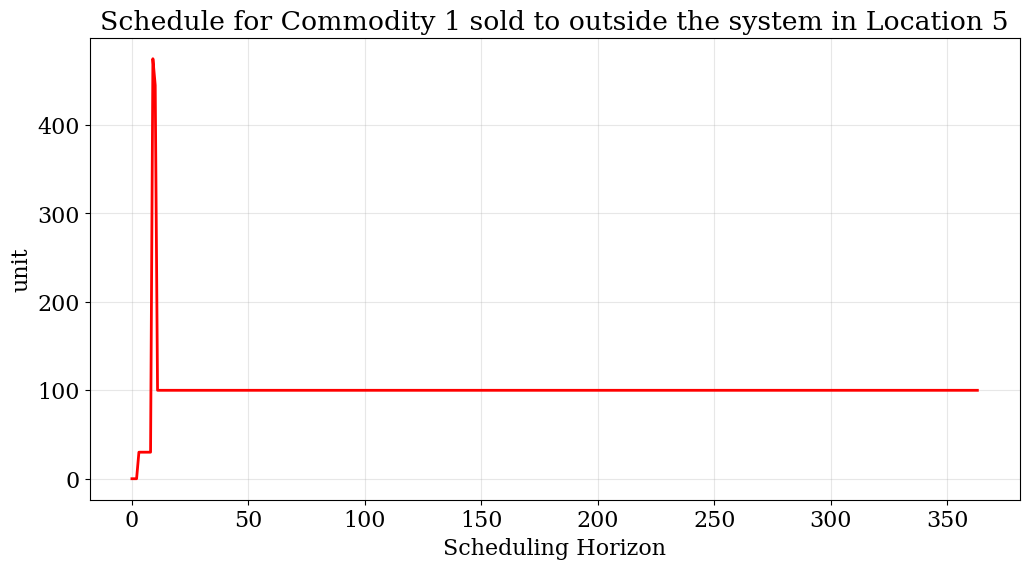

In [12]:
plot_results.schedule(results=cl_step2_load_results, y_axis='S', component='com1_sold', location='loc5', color='red')

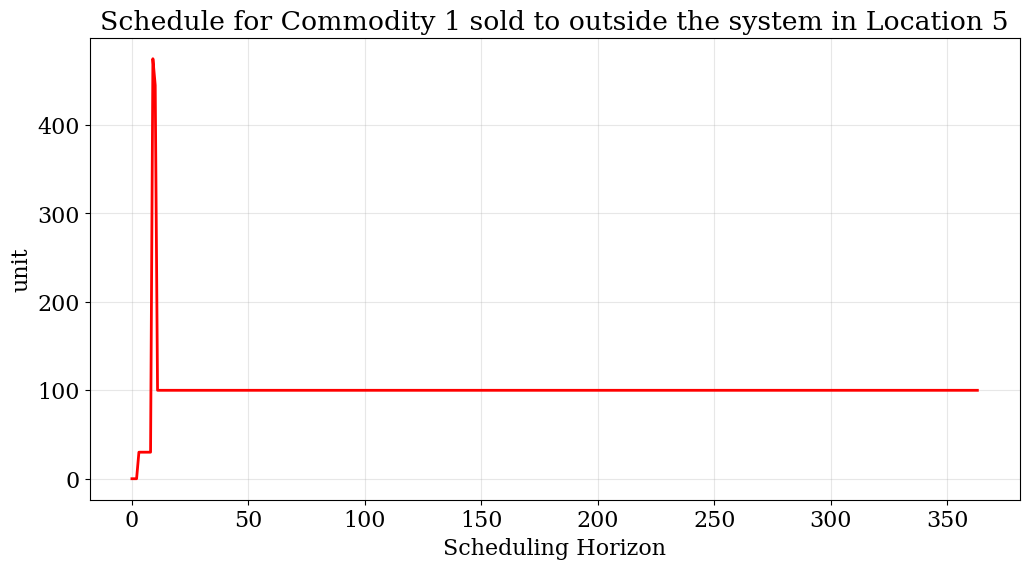

In [13]:
plot_results.schedule(results=cl_step2_ncl_des_load_results, y_axis='S', component='com1_sold', location='loc5', color='red')

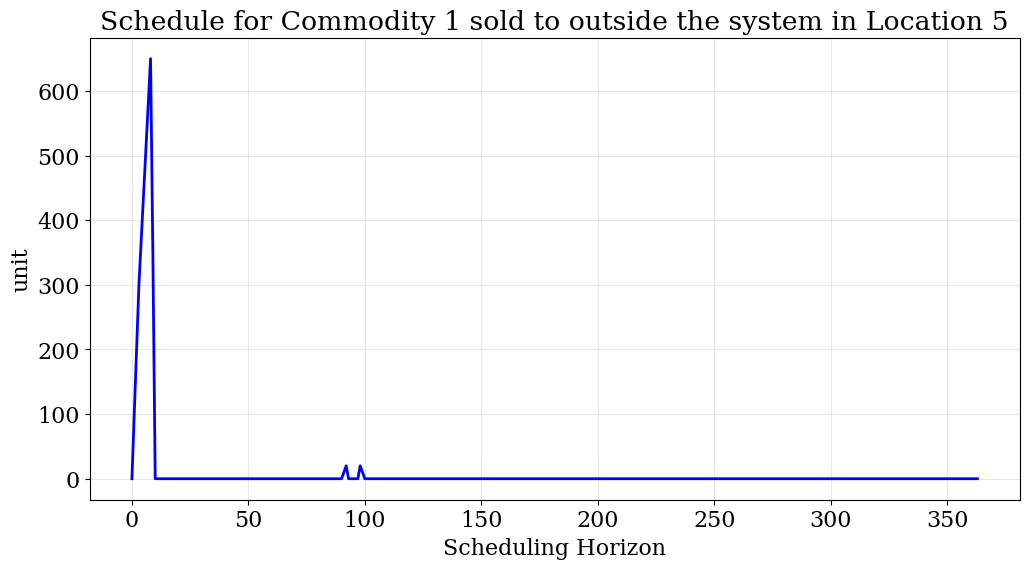

In [14]:
plot_results.schedule(results=ncl_load_results, y_axis='Demand_backlog', component='com1_sold', location='loc5')

In [15]:
# a = ncl_load_results.output['Demand_backlog_cost_network']['com1_sold',0] + ncl_load_results.output['Demand_penalty_cost_network']['com1_sold',0]
a = ncl_load_results.output['objective']
# b = cl_load_results.output['Demand_backlog_cost_network']['com1_sold',0] + cl_load_results.output['Demand_penalty_cost_network']['com1_sold',0]
b = cl_load_results.output['objective']
(b-a)/a

0.02519276381370533

In [16]:
# # a = ph30_ncl_load_results.output['Demand_backlog_cost_network']['com1_sold',0] + ph30_ncl_load_results.output['Demand_penalty_cost_network']['com1_sold',0]
# a = ph30_ncl_load_results.output['objective']
# # b = ph30_cl_load_results.output['Demand_backlog_cost_network']['com1_sold',0] + ph30_cl_load_results.output['Demand_penalty_cost_network']['com1_sold',0]
# b = ph30_cl_load_results.output['objective']
# (b-a)/a

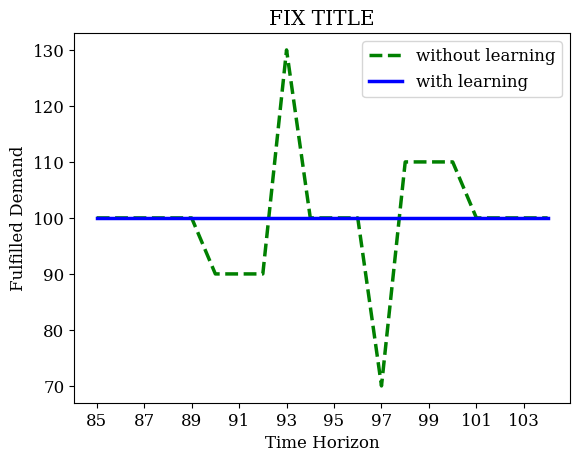

In [17]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots()

# Plot data from the first dataset
start=85
end = start+20

ax.plot(range(start, end), list(value for key, value in ncl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='without learning', color='green', linestyle='--', linewidth='2.5')

ax.plot(range(start, end), list(value for key, value in cl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='with learning', color='blue', linestyle='-', linewidth='2.5')

# ax.plot(range(start, end), list(value for key, value in ph30_ncl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='without learning (ph 30)', color='green', linestyle='--', linewidth='2.5')
# 
# ax.plot(range(start, end), list(value for key, value in ph30_cl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='with learning (ph 30)', color='green', linestyle='-', linewidth='2.5')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Fulfilled Demand')
ax.set_title('FIX TITLE')
ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
# plt.grid(alpha=0.6)
plt.rcdefaults()
plt.savefig(fname = 'cl_ncl_compare', dpi = 300)
# Show the plot
plt.show()

In [18]:
# rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
# rc('text', usetex=False)
# fig, ax = plt.subplots()
# 
# # Plot data from the first dataset
# start=88
# end = start+15
# 
# ax.plot(range(start, end), list(value for key, value in ncl_load_results.output['Demand_backlog_cost'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], color='green', linestyle='--', linewidth='2.5')
# 
# ax.plot(range(start, end), list(value for key, value in cl_load_results.output['Demand_backlog_cost'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='with learning', color='green', linestyle='-', linewidth='2.5')
# 
# ax.plot(range(start, end), list(value for key, value in ph30_ncl_load_results.output['Demand_backlog_cost'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], color='blue', linestyle='--', linewidth='2.5')
# 
# ax.plot(range(start, end), list(value for key, value in ph30_cl_load_results.output['Demand_backlog_cost'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='with learning (ph 30)', color='blue', linestyle='-', linewidth='2.5')
# 
# # Customize the plot
# ax.set_xlabel('Time Horizon')
# ax.set_ylabel('Fulfilled Demand')
# ax.set_title('Amount delivered at customer node')
# ax.legend()
# ax.plot(linewidth=0.5)
# ax.set_xticks(range(start, end, 2))
# # plt.grid(alpha=0.6)
# plt.rcdefaults()
# # plt.savefig(fname = 'cl_ncl_compare', dpi = 300)
# # Show the plot
# plt.show()

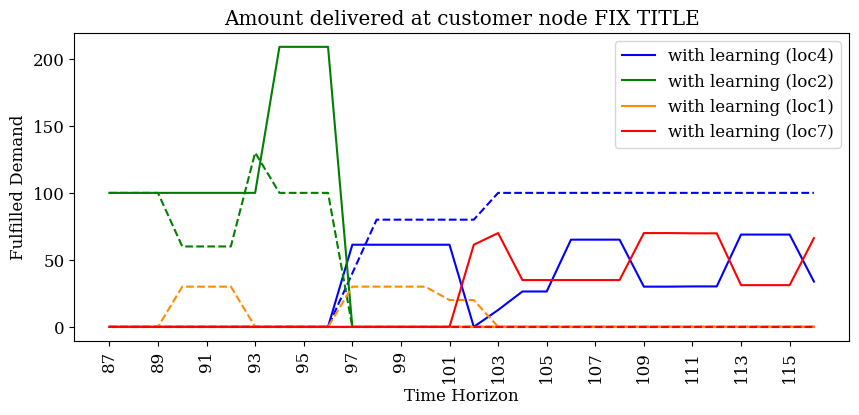

In [19]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots(figsize=(10,4))

# Plot data from the first dataset
start=87
end = start+30
focal_results_1 = cl_load_results
focal_results_2 = ncl_load_results

r_cl_loc4 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc4')[start:end]
r_ncl_loc4 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc4')[start:end]

r_cl_loc2 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc2')[start:end]
r_ncl_loc2 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc2')[start:end]

r_cl_loc1 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc1')[start:end]
r_ncl_loc1 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc1')[start:end]

r_cl_loc7 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc7')[start:end]
r_ncl_loc7 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc7')[start:end]

r_cl_dis5 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end]
r_ncl_dis5 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end]

# r_cl_tot5 = [a+b+c+d+e for a,b,c,d,e in zip(r_cl_loc1, r_cl_loc7, r_cl_dis5, r_cl_loc4, r_cl_loc2)]

ax.plot(range(start, end), r_cl_loc4, label='with learning (loc4)', color='blue', linestyle='-')
ax.plot(range(start, end), r_ncl_loc4, color='blue', linestyle='--')

ax.plot(range(start, end), r_cl_loc2, label='with learning (loc2)', color='green', linestyle='-')
ax.plot(range(start, end), r_ncl_loc2, color='green', linestyle='--')

ax.plot(range(start, end), r_cl_loc1, label='with learning (loc1)', color='darkorange', linestyle='-')
ax.plot(range(start, end), r_ncl_loc1, color='darkorange', linestyle='--')

ax.plot(range(start, end), r_cl_loc7, label='with learning (loc7)', color='red', linestyle='-')
ax.plot(range(start, end), r_ncl_loc7, color='red', linestyle='--')

# ax.plot(range(start, end), r_cl_dis5, label='with learning (dis5)', color='cyan', linestyle='-')
# ax.plot(range(start, end), r_ncl_dis5, color='cyan', linestyle='--')

# ax.plot(range(start, end), r_cl_tot5, label='with learning (tot5)', color='black', linestyle='-')

# ax.plot(range(start, end), list(value for key, value in ncl_load_results.output['P'].items() if key[0]=='loc2' and key[1]=='com1_process')[start:end], label='without learning (loc2 process)', color='blue', linestyle='-.')
# ax.plot(range(start, end), list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc2' and key[1]=='com1_process')[start:end], label='with learning (loc2 process)', color='red', linestyle='-.')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Fulfilled Demand')
ax.set_title('Amount delivered at customer node FIX TITLE')
ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
plt.xticks(rotation=90)
# plt.grid(alpha=0.6)
plt.rcdefaults()
plt.savefig(fname = 'customer_node_delivery_compare', dpi = 300)
# Show the plot
plt.show()

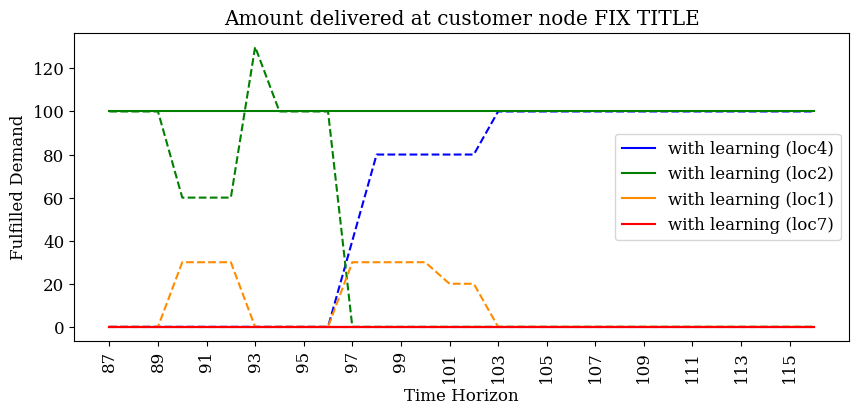

In [21]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots(figsize=(10,4))

# Plot data from the first dataset
start=87
end = start+30
focal_results_1 = cl_step2_ncl_des_load_results
focal_results_2 = ncl_load_results

r_cl_loc4 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc4')[start:end]
r_ncl_loc4 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc4')[start:end]

r_cl_loc2 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc2')[start:end]
r_ncl_loc2 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc2')[start:end]

r_cl_loc1 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc1')[start:end]
r_ncl_loc1 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc1')[start:end]

r_cl_loc7 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc7')[start:end]
r_ncl_loc7 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc7')[start:end]

r_cl_dis5 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end]
r_ncl_dis5 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end]

# r_cl_tot5 = [a+b+c+d+e for a,b,c,d,e in zip(r_cl_loc1, r_cl_loc7, r_cl_dis5, r_cl_loc4, r_cl_loc2)]

ax.plot(range(start, end), r_cl_loc4, label='with learning (loc4)', color='blue', linestyle='-')
ax.plot(range(start, end), r_ncl_loc4, color='blue', linestyle='--')

ax.plot(range(start, end), r_cl_loc2, label='with learning (loc2)', color='green', linestyle='-')
ax.plot(range(start, end), r_ncl_loc2, color='green', linestyle='--')

ax.plot(range(start, end), r_cl_loc1, label='with learning (loc1)', color='darkorange', linestyle='-')
ax.plot(range(start, end), r_ncl_loc1, color='darkorange', linestyle='--')

ax.plot(range(start, end), r_cl_loc7, label='with learning (loc7)', color='red', linestyle='-')
ax.plot(range(start, end), r_ncl_loc7, color='red', linestyle='--')

# ax.plot(range(start, end), r_cl_dis5, label='with learning (dis5)', color='cyan', linestyle='-')
# ax.plot(range(start, end), r_ncl_dis5, color='cyan', linestyle='--')

# ax.plot(range(start, end), r_cl_tot5, label='with learning (tot5)', color='black', linestyle='-')

# ax.plot(range(start, end), list(value for key, value in ncl_load_results.output['P'].items() if key[0]=='loc2' and key[1]=='com1_process')[start:end], label='without learning (loc2 process)', color='blue', linestyle='-.')
# ax.plot(range(start, end), list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc2' and key[1]=='com1_process')[start:end], label='with learning (loc2 process)', color='red', linestyle='-.')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Fulfilled Demand')
ax.set_title('Amount delivered at customer node FIX TITLE')
ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
plt.xticks(rotation=90)
# plt.grid(alpha=0.6)
plt.rcdefaults()
plt.savefig(fname = 'customer_node_delivery_compare', dpi = 300)
# Show the plot
plt.show()

In [22]:
# rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
# rc('text', usetex=False)
# fig, ax = plt.subplots(figsize=(10,4))
# 
# # Plot data from the first dataset
# start=87
# end = start+30
# 
# r_cl_step2_loc4 = list(value for key, value in cl_step2_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc4')[start:end]
# r_cl_loc4 = list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc4')[start:end]
# 
# r_cl_step2_loc2 = list(value for key, value in cl_step2_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc2')[start:end]
# r_cl_loc2 = list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc2')[start:end]
# 
# r_cl_step2_loc1 = list(value for key, value in cl_step2_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc1')[start:end]
# r_cl_loc1 = list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc1')[start:end]
# 
# r_cl_step2_loc7 = list(value for key, value in cl_step2_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc7')[start:end]
# r_cl_loc7 = list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc7')[start:end]
# 
# r_cl_step2_dis5 = list(value for key, value in cl_step2_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end]
# r_cl_dis5 = list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end]
# 
# # r_cl_step2_tot5 = [a+b+c+d+e for a,b,c,d,e in zip(r_cl_step2_loc1, r_cl_step2_loc7, r_cl_step2_dis5, r_cl_step2_loc4, r_cl_step2_loc2)]
# 
# ax.plot(range(start, end), r_cl_step2_loc4, label='with step2 learning (loc4)', color='blue', linestyle='-')
# ax.plot(range(start, end), r_cl_loc4, color='blue', linestyle='--')
# 
# ax.plot(range(start, end), r_cl_step2_loc2, label='with step2 learning (loc2)', color='green', linestyle='-')
# ax.plot(range(start, end), r_cl_loc2, color='green', linestyle='--')
# 
# ax.plot(range(start, end), r_cl_step2_loc1, label='with step2 learning (loc1)', color='darkorange', linestyle='-')
# ax.plot(range(start, end), r_cl_loc1, color='darkorange', linestyle='--')
# 
# ax.plot(range(start, end), r_cl_step2_loc7, label='with step2 learning (loc7)', color='red', linestyle='-')
# ax.plot(range(start, end), r_cl_loc7, color='red', linestyle='--')
# 
# # ax.plot(range(start, end), r_cl_step2_dis5, label='with step2 learning (dis5)', color='cyan', linestyle='-')
# # ax.plot(range(start, end), r_cl_dis5, color='cyan', linestyle='--')
# 
# # ax.plot(range(start, end), r_cl_step2_tot5, label='with step2 learning (tot5)', color='black', linestyle='-')
# 
# # ax.plot(range(start, end), list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc2' and key[1]=='com1_process')[start:end], label='without learning (loc2 process)', color='blue', linestyle='-.')
# # ax.plot(range(start, end), list(value for key, value in cl_step2_load_results.output['P'].items() if key[0]=='loc2' and key[1]=='com1_process')[start:end], label='with step2 learning (loc2 process)', color='red', linestyle='-.')
# 
# # Customize the plot
# ax.set_xlabel('Time Horizon')
# ax.set_ylabel('Fulfilled Demand')
# ax.set_title('Amount delivered at customer node FIX TITLE')
# ax.legend()
# ax.plot(linewidth=0.5)
# ax.set_xticks(range(start, end, 2))
# plt.xticks(rotation=90)
# # plt.grid(alpha=0.6)
# plt.rcdefaults()
# plt.savefig(fname = 'customer_node_delivery_compare', dpi = 300)
# # Show the plot
# plt.show()

In [19]:
# x = list(range(len(list(value for key, value in ncl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold'))))
# y = list(value for key, value in ncl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')
# # y2 = [556280.48, 383540.86, 373214.82, 645751.8, 437765.47]
# # Plotting
# plt.plot(x, y, marker='', label='Location 5')  # 'o' adds circular markers at data points
# # plt.plot(x, y2, marker='x', label='approx_obj')
# plt.title('Delivery under demand variability')
# plt.xlabel('Time Horizon')
# plt.ylabel('Delivery Level')
# plt.grid(True)
# plt.legend()
# plt.savefig(fname = 'MPC_demand', dpi = 300)
# plt.show()

In [20]:
# x = list(range(len(list(value for key, value in ncl_load_results.output['Demand_penalty'].items() if key[0]=='loc5' and key[1]=='com1_sold'))))
# y = list(value for key, value in ncl_load_results.output['Demand_penalty'].items() if key[0]=='loc5' and key[1]=='com1_sold')
# # y2 = [556280.48, 383540.86, 373214.82, 645751.8, 437765.47]
# # Plotting
# plt.plot(x, y, marker='', label='Location 5')  # 'o' adds circular markers at data points
# # plt.plot(x, y2, marker='x', label='approx_obj')
# plt.title('Unmet demand under demand variability')
# plt.xlabel('Time Horizon')
# plt.ylabel('Unmet Demand Level')
# plt.grid(True)
# plt.legend()
# plt.savefig(fname = 'MPC_demand_penalty', dpi = 300)
# plt.show()

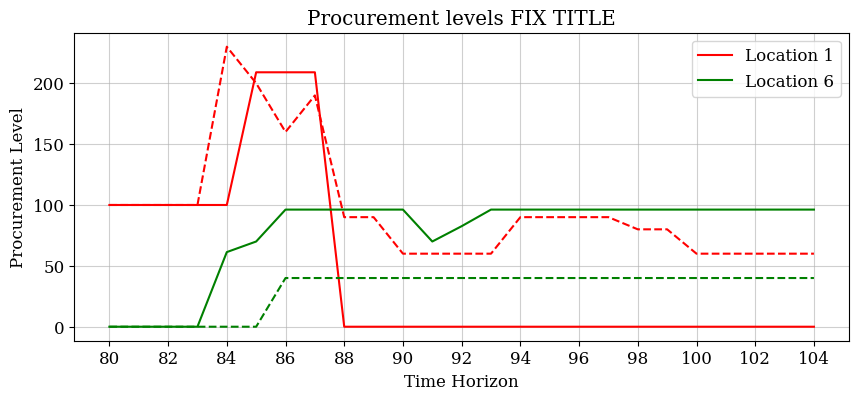

In [23]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots(figsize=(10,4))

# Plot data from the first dataset
start=80
end = start+25

focal_results_1 = cl_load_results
focal_results_2 = ncl_load_results

ax.plot(range(start, end), list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc1' and key[1]=='procure com1')[start:end], label='Location 1', color='red', linestyle='-')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc1' and key[1]=='procure com1')[start:end], color='red', linestyle='--')

ax.plot(range(start, end), list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc6' and key[1]=='procure com1')[start:end], label='Location 6', color='green', linestyle='-')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc6' and key[1]=='procure com1')[start:end], color='green', linestyle='--')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Procurement Level')
ax.set_title('Procurement levels FIX TITLE')
ax.set_xticks(range(start, end, 2))
ax.legend()
ax.plot(linewidth=0.5)
plt.grid(alpha=0.6)
plt.rcdefaults()
plt.savefig(fname = 'MPC_procurement_compare', dpi = 300)
# Show the plot
plt.show()

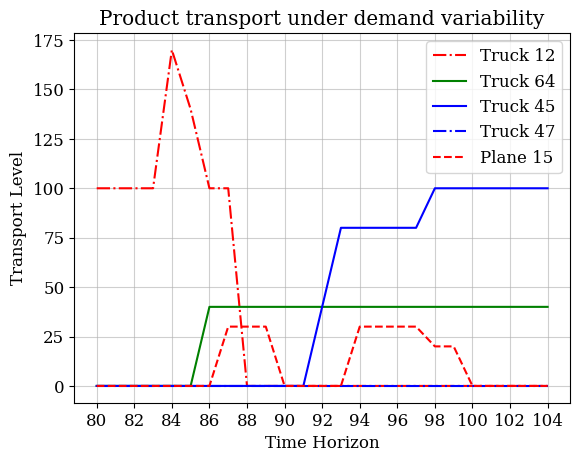

In [24]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots()

# Plot data from the first dataset
start=80
end = start+25

focal_results_1 = ncl_load_results

a=1
b=2
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='red', linestyle='-.')

a=6
b=4
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='green', linestyle='-')

a=4
b=5
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='blue', linestyle='-')

a=4
b=7
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='blue', linestyle='-.')

a=1
b=5
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'plane{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Plane {a}{b}', color='red', linestyle='--')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Transport Level')
ax.set_title('Product transport under demand variability')
ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
plt.grid(alpha=0.6)
plt.rcdefaults()
# plt.savefig(fname = 'MPC_logistics', dpi = 300)
# Show the plot
plt.show()

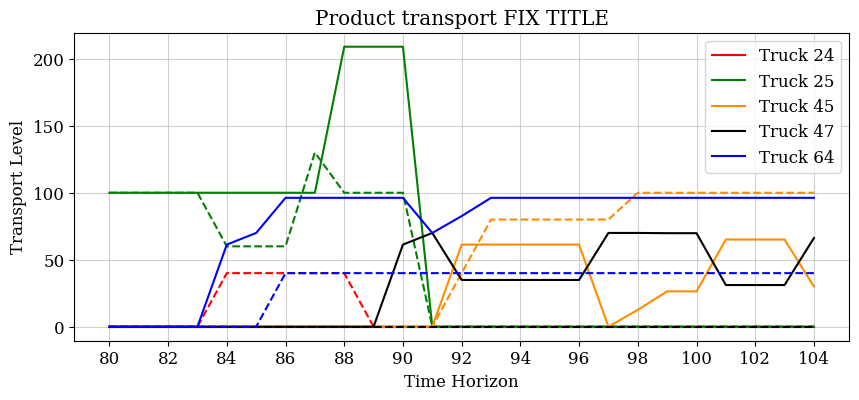

In [26]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots(figsize=(10,4))

# Plot data from the first dataset
start=80
end = start+25

focal_results_1 = ncl_load_results
focal_results_2 = cl_load_results

a=2
b=4
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='red', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='red', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='red', linestyle='-')

a=2
b=5
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='green', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='green', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='green', linestyle='-')

a=4
b=5
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='yellow', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='darkorange', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='darkorange', linestyle='-')

a=4
b=7
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='black', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='black', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='black', linestyle='-')

a=6
b=4
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='black', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='blue', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='blue', linestyle='-')

# a=3
# b=4
# # ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='black', linestyle='--')
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='brown', linestyle='--')
# ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='brown', linestyle='-')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Transport Level')
ax.set_title('Product transport FIX TITLE')
ax.legend(loc='upper right')
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
plt.grid(alpha=0.6)
plt.rcdefaults()
plt.savefig(fname = 'MPC_logistics_compare', dpi = 300)
# Show the plot
plt.show()

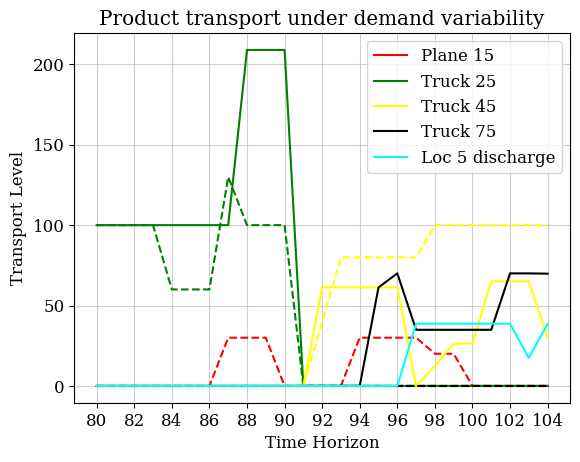

In [27]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots()

# Plot data from the first dataset
start=80
end = start+25

focal_results_1 = ncl_load_results
focal_results_2 = cl_load_results

a=1
b=5
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='red', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'plane{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='red', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'plane{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Plane {a}{b}', color='red', linestyle='-')

a=2
b=5
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='green', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='green', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='green', linestyle='-')

a=4
b=5
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='yellow', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='yellow', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='yellow', linestyle='-')

a=7
b=5
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='black', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='black', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='black', linestyle='-')

ax.plot(range(start, end), list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end], label='Loc 5 discharge', color='cyan', linestyle='-')
# ax.plot(range(start, end), list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_process')[start:end], label='Loc 5 process', color='cyan', linestyle='-')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Transport Level')
ax.set_title('Product transport under demand variability')
ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
plt.grid(alpha=0.6)
plt.rcdefaults()
# plt.savefig(fname = 'MPC_logistics', dpi = 300)
# Show the plot
plt.show()

In [28]:
ncl_load_results.output['objective']

835327.3999999999

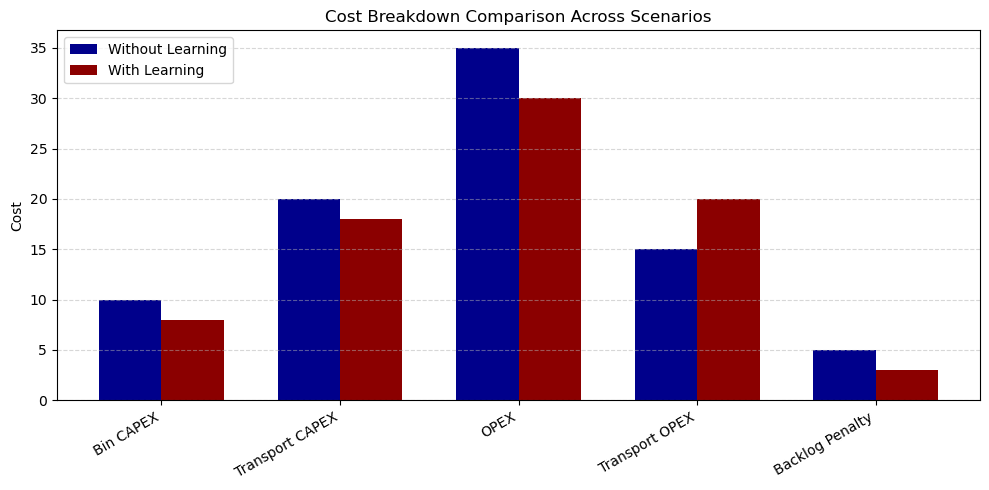

In [73]:
# --- Input Data -------------------------------------------------------------
categories = ["Bin CAPEX", "Transport CAPEX", "OPEX", "Transport OPEX", "Backlog Penalty"]

# Replace these with your actual values
scenario1 = [10, 20, 35, 15, 5]    # e.g., without learning
scenario2 = [8, 18, 30, 20, 3]     # e.g., with learning

# Labels for scenarios
scenario_labels = ["Without Learning", "With Learning"]

# --- Plotting ---------------------------------------------------------------
x = np.arange(len(categories))       # positions of categories
width = 0.35                         # width of each bar

fig, ax = plt.subplots(figsize=(10, 5))

# Bars
bars1 = ax.bar(x - width/2, scenario1, width, label=scenario_labels[0], color='darkblue')
bars2 = ax.bar(x + width/2, scenario2, width, label=scenario_labels[1], color='darkred')

# --- Labels & Styling -------------------------------------------------------
ax.set_ylabel("Cost")
ax.set_title("Cost Breakdown Comparison Across Scenarios")
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=30, ha='right')
ax.legend(loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()
